# 02. Exploratory Data Analysis

**Note:** This jupyter notebook was executed in Google Colab environment

Now it is time to take a closer look at the data

## Import Packages

In [1]:
import os
import pandas as pd
from PIL import Image, ImageDraw
import ast
import requests
import matplotlib.pyplot as plt
import math

## Load data

The previous notebook created several CSV files.

First, let us load them.

In [2]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv
!gdown 1_Lrjiijqh0Dd4Y2yjvLx4jIMehe9b31O # annotations_raw.csv
!gdown 1hOdCv5vZBw3XaWilE1-a5suA62p455En # images.csv
!gdown 1RXzKS5HV0ylQZUsYdj2YnFdH1BxCzmtw # scene_anotations.csv
!gdown 1xJ4tw1mlxz5-upkxZWVHZCpG8bJUZsRK # categories.csv
!gdown 1m6DMubUBbDk68DsMWdo7pE8aYOegXv3Y # scene_categories.csv

Downloading...
From: https://drive.google.com/uc?id=1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt
To: /content/annotations_processed.csv
100% 3.10M/3.10M [00:00<00:00, 158MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_Lrjiijqh0Dd4Y2yjvLx4jIMehe9b31O
To: /content/annotations_raw.csv
100% 1.98M/1.98M [00:00<00:00, 161MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hOdCv5vZBw3XaWilE1-a5suA62p455En
To: /content/images.csv
100% 258k/258k [00:00<00:00, 102MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RXzKS5HV0ylQZUsYdj2YnFdH1BxCzmtw
To: /content/scene_annotations.csv
100% 42.9k/42.9k [00:00<00:00, 73.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xJ4tw1mlxz5-upkxZWVHZCpG8bJUZsRK
To: /content/categories.csv
100% 1.71k/1.71k [00:00<00:00, 6.47MB/s]
Downloading...
From: https://drive.google.com/uc?id=1m6DMubUBbDk68DsMWdo7pE8aYOegXv3Y
To: /content/scene_categories.csv
100% 101/101 [00:00<00:00, 500kB/s]


In [3]:
!ls -la

total 1592492
drwxr-xr-x 1 root root       4096 Jun 24 10:59 .
drwxr-xr-x 1 root root       4096 Jun 24 07:55 ..
-rw-r--r-- 1 root root    3103625 Jun 23 16:28 annotations_processed.csv
-rw-r--r-- 1 root root    1978579 Jun 23 16:28 annotations_raw.csv
-rw-r--r-- 1 root root       1714 Jun 23 16:28 categories.csv
drwxr-xr-x 4 root root       4096 Jun  4 13:32 .config
-rw-r--r-- 1 root root     257651 Jun 23 16:28 images.csv
drwxr-xr-x 1 root root       4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root      42919 Jun 23 16:28 scene_annotations.csv
-rw-r--r-- 1 root root        101 Jun 23 16:28 scene_categories.csv
-rw-r--r-- 1 root root 1625292800 Jun 24 08:11 taco.zipohhgevp6.part


## Set Environment Paths

In [4]:
def is_google_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

## Init dataframes

In [5]:
df_images = pd.read_csv(os.path.join(ROOT_PATH, "images.csv"))
df_annotations = pd.read_csv(os.path.join(ROOT_PATH, "annotations_raw.csv"))
df_categories = pd.read_csv(os.path.join(ROOT_PATH, "categories.csv"))
df_scene_annotations = pd.read_csv(os.path.join(ROOT_PATH, "scene_annotations.csv"))
df_scene_categories = pd.read_csv(os.path.join(ROOT_PATH, "scene_categories.csv"))
df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))

## Aggregations

Let us build simple aggregations for the dataframe

### 1. Common data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4784 entries, 0 to 4783
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              4784 non-null   int64  
 1   image_id        4784 non-null   int64  
 2   category_id     4784 non-null   int64  
 3   segmentation    4784 non-null   object 
 4   area            4784 non-null   float64
 5   bbox            4784 non-null   object 
 6   iscrowd         4784 non-null   int64  
 7   id_img          4784 non-null   int64  
 8   width           4784 non-null   int64  
 9   height          4784 non-null   int64  
 10  file_name       4784 non-null   object 
 11  license         2632 non-null   object 
 12  flickr_url      4784 non-null   object 
 13  coco_url        0 non-null      float64
 14  date_captured   0 non-null      float64
 15  flickr_640_url  3328 non-null   object 
 16  supercategory   4784 non-null   object 
 17  id_cat          4784 non-null   i

In [7]:
df.describe()

,id,image_id,category_id,area,iscrowd,id_img,width,height,coco_url,date_captured,id_cat
count,4784.000000,4784.000000,4784.000000,4.784000e+03,4784.0,4784.000000,4784.000000,4784.000000,0.0,0.0,4784.000000
mean,2391.949833,756.936037,34.079013,1.504072e+05,0.0,756.936037,2794.278428,3234.358278,NaN,NaN,34.079013
std,1381.264283,445.884396,20.081707,4.850848e+05,0.0,445.884396,714.851079,837.244672,NaN,NaN,20.081707
min,1.000000,0.000000,0.000000,5.550000e+01,0.0,0.000000,842.000000,474.000000,NaN,NaN,0.000000
25%,1195.750000,354.750000,12.000000,2.142000e+03,0.0,354.750000,2448.000000,2448.000000,NaN,NaN,12.000000
50%,2392.500000,743.000000,36.000000,1.424475e+04,0.0,743.000000,2448.000000,3264.000000,NaN,NaN,36.000000
75%,3588.250000,1154.000000,57.000000,7.533312e+04,0.0,1154.000000,3264.000000,4000.000000,NaN,NaN,57.000000
max,4783.000000,1499.000000,59.000000,7.328036e+06,0.0,1499.000000,6000.000000,5312.000000,NaN,NaN,59.000000


In [8]:
df['category_id'].nunique()

59

In [9]:
df['supercategory'].nunique()

28

`59` overall categories with `28` supercategories

Both values seem too large for stable training with the current dataset size.

### 2. Missing Values / Duplicates

In [10]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
coco_url,4784
date_captured,4784
license,2152
flickr_640_url,1456
segmentation,0
category_id,0
image_id,0
id,0
id_img,0
area,0


In [11]:
df.duplicated().sum()

np.int64(0)

#### Observations

* Before model training, it is important to check that required fields such as image paths, categories, bounding boxes, and segmentation polygons are present.

### Dataset structure

In [12]:
df.head(10)

,id,image_id,category_id,segmentation,area,bbox,iscrowd,id_img,width,height,file_name,license,flickr_url,coco_url,date_captured,flickr_640_url,supercategory,id_cat,category_name,file_path
0,1,0,6,"[[561.0, 1238.0, 568.0, 1201.0, 567.0, 1175.0,...",403954.0,"[517.0, 127.0, 447.0, 1322.0]",0,0,1537,2049,batch_1/000006.jpg,NaN,https://farm66.staticflickr.com/65535/33978196...,NaN,NaN,https://farm66.staticflickr.com/65535/33978196...,Bottle,6,Glass bottle,/content/taco/batch_1/000006.jpg
1,2,1,18,"[[928.0, 1876.0, 938.0, 1856.0, 968.0, 1826.0,...",1071259.5,"[1.0, 457.0, 1429.0, 1519.0]",0,1,1537,2049,batch_1/000008.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Carton,18,Meal carton,/content/taco/batch_1/000008.jpg
2,3,1,14,"[[617.0, 383.0, 703.0, 437.0, 713.0, 456.0, 72...",99583.5,"[531.0, 292.0, 1006.0, 672.0]",0,1,1537,2049,batch_1/000008.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Carton,14,Other carton,/content/taco/batch_1/000008.jpg
3,4,2,5,"[[670.0, 993.0, 679.0, 998.0, 684.0, 1001.0, 6...",73832.5,"[632.0, 987.0, 500.0, 374.0]",0,2,1537,2049,batch_1/000010.jpg,NaN,https://farm66.staticflickr.com/65535/40888872...,NaN,NaN,https://farm66.staticflickr.com/65535/40888872...,Bottle,5,Clear plastic bottle,/content/taco/batch_1/000010.jpg
4,5,2,7,"[[647.0, 1028.0, 650.0, 1022.0, 653.0, 1016.0,...",915.0,"[632.0, 989.0, 44.0, 51.0]",0,2,1537,2049,batch_1/000010.jpg,NaN,https://farm66.staticflickr.com/65535/40888872...,NaN,NaN,https://farm66.staticflickr.com/65535/40888872...,Bottle cap,7,Plastic bottle cap,/content/taco/batch_1/000010.jpg
5,6,3,5,"[[354.0, 1268.0, 351.0, 1252.0, 347.0, 1237.0,...",98379.5,"[209.0, 920.0, 454.0, 562.0]",0,3,2049,1537,batch_1/000019.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Bottle,5,Clear plastic bottle,/content/taco/batch_1/000019.jpg
6,7,3,5,"[[1239.0, 841.0, 1247.0, 842.0, 1252.0, 835.0,...",43678.0,"[1212.0, 822.0, 179.0, 446.0]",0,3,2049,1537,batch_1/000019.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Bottle,5,Clear plastic bottle,/content/taco/batch_1/000019.jpg
7,8,3,7,"[[643.0, 1453.0, 649.0, 1445.0, 653.0, 1442.0,...",578.5,"[634.0, 1442.0, 29.0, 39.0]",0,3,2049,1537,batch_1/000019.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Bottle cap,7,Plastic bottle cap,/content/taco/batch_1/000019.jpg
8,9,3,12,"[[730.0, 852.0, 700.0, 810.0, 686.0, 789.0, 68...",61402.0,"[589.0, 548.0, 341.0, 405.0]",0,3,2049,1537,batch_1/000019.jpg,NaN,https://farm66.staticflickr.com/65535/47803331...,NaN,NaN,https://farm66.staticflickr.com/65535/47803331...,Can,12,Drink can,/content/taco/batch_1/000019.jpg
9,10,4,12,"[[1032.0, 1170.0, 1040.0, 1144.0, 1046.0, 1125...",93266.0,"[556.0, 944.0, 490.0, 336.0]",0,4,1537,2049,batch_1/000026.jpg,NaN,https://farm66.staticflickr.com/65535/33978199...,NaN,NaN,https://farm66.staticflickr.com/65535/33978199...,Can,12,Drink can,/content/taco/batch_1/000026.jpg


From the dataframe structure, we can see that each row represents one annotated object in a particular image. Each object has a segmentation mask and a bounding box.

Let us check how many objects each image contains.

In [13]:
df.groupby('image_id').size().sort_values(ascending=False)

,0
image_id,
1107,90
1321,54
362,38
727,37
363,37
...,...
534,1
1492,1
1491,1


Most images contain only a few objects, but there are strong outliers. One image contains 90 annotated objects.

This is important for training because images with many objects can increase memory usage and make optimization less stable.

In [14]:
df.groupby('image_id').size().sort_values(ascending=False).head(30)

,0
image_id,
1107,90
1321,54
362,38
727,37
363,37
426,37
1112,30
630,29
1365,28


## Categories

### Images per supercategory

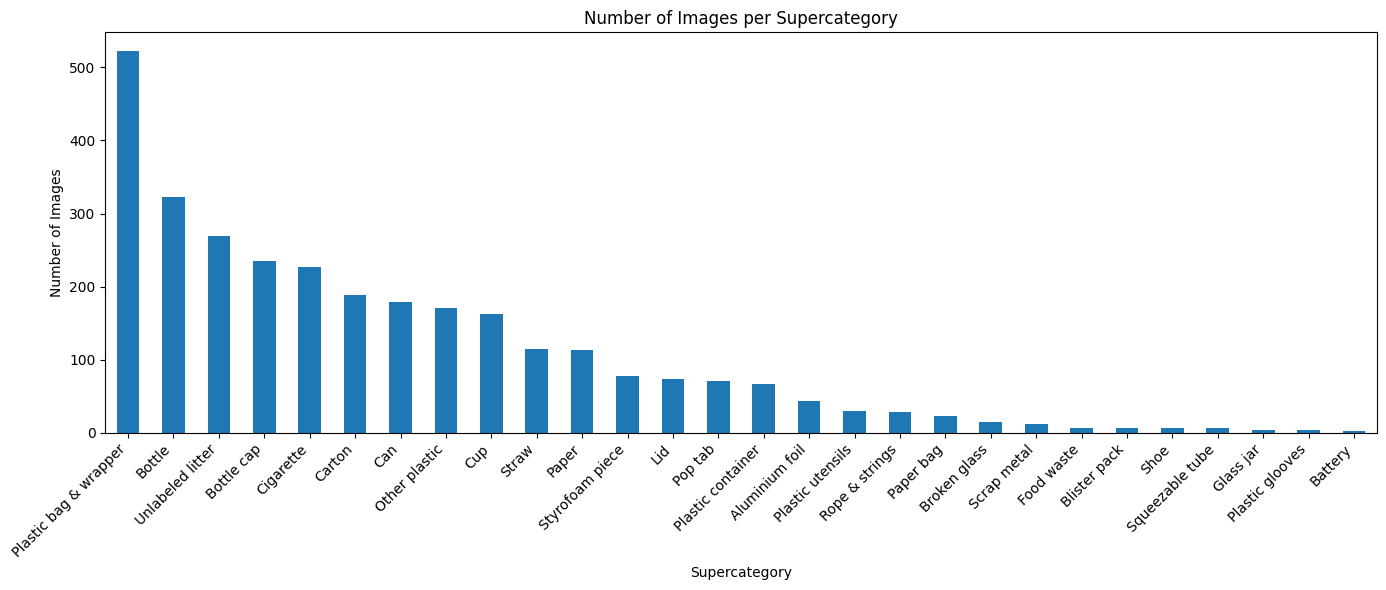

In [15]:
images_per_supercategory = (
    df[["image_id", "supercategory"]]
    .drop_duplicates()
    .groupby("supercategory")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
images_per_supercategory.plot(kind="bar")
plt.title("Number of Images per Supercategory")
plt.xlabel("Supercategory")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Object count per supercategory

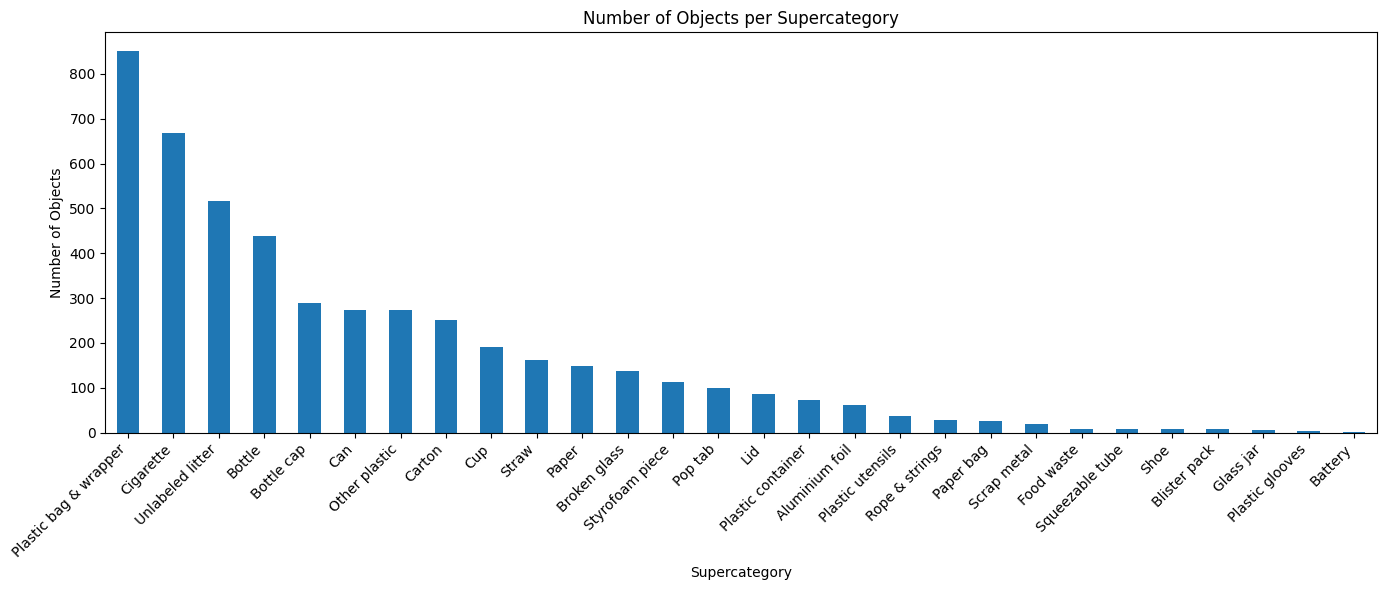

In [16]:
objects_per_supercategory = (
    df["supercategory"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
objects_per_supercategory.plot(kind="bar")
plt.title("Number of Objects per Supercategory")
plt.xlabel("Supercategory")
plt.ylabel("Number of Objects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Images Per Category

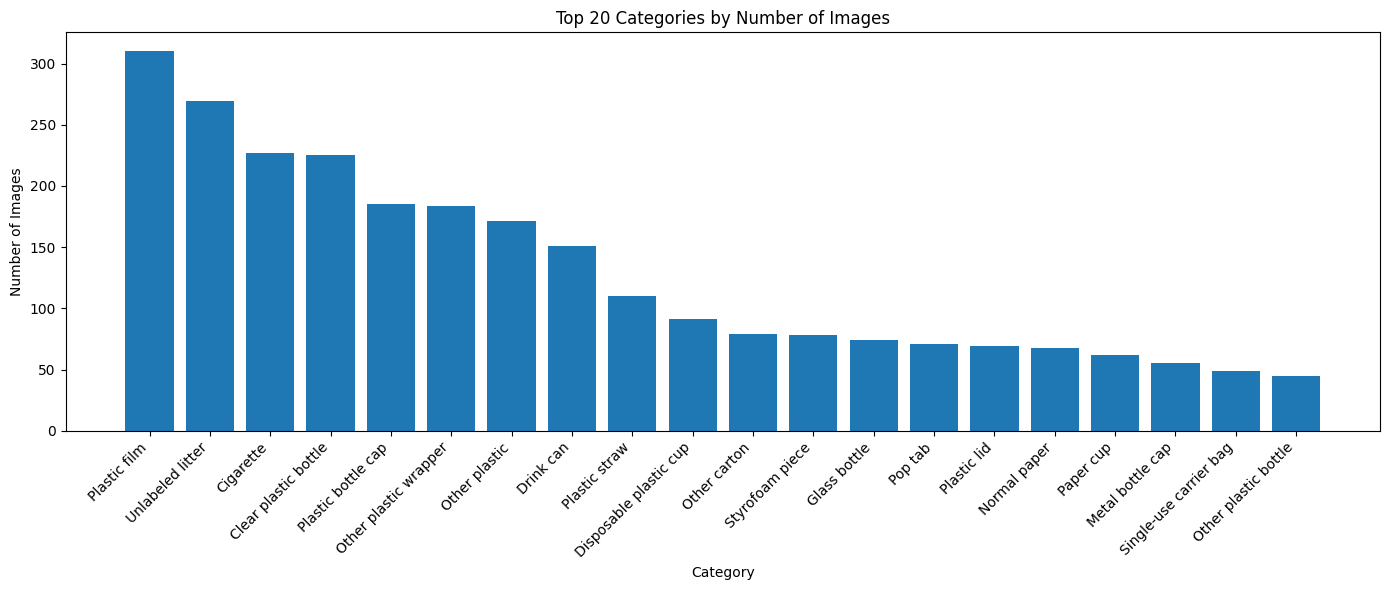

In [17]:
images_per_category = (
    df[["image_id", "category_id", "category_name"]]
    .drop_duplicates()
    .groupby(["category_id", "category_name"])
    .size()
    .reset_index(name="num_images")
    .sort_values("num_images", ascending=False)
)

top_categories = images_per_category.head(20)

plt.figure(figsize=(14, 6))
plt.bar(top_categories["category_name"], top_categories["num_images"])
plt.title("Top 20 Categories by Number of Images")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Objects Per Category

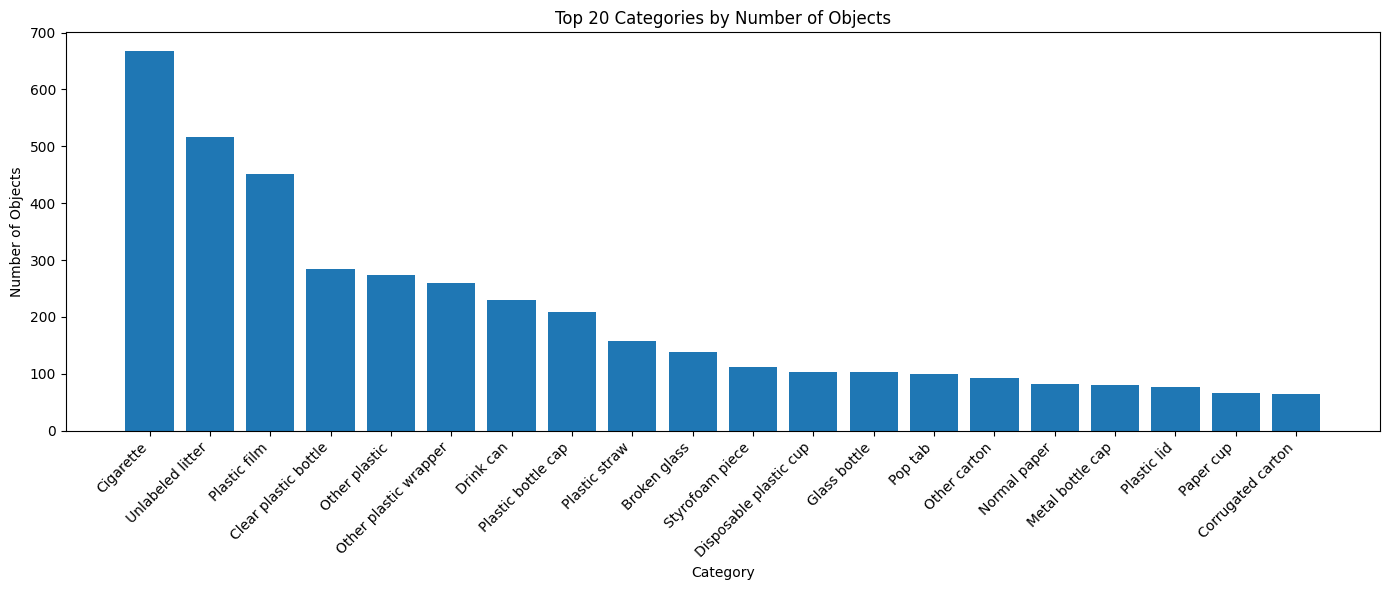

In [18]:
objects_per_category = (
    df.groupby(["category_id", "category_name"])
    .size()
    .reset_index(name="num_objects")
    .sort_values("num_objects", ascending=False)
)

top_objects_categories = objects_per_category.head(20)

plt.figure(figsize=(14, 6))
plt.bar(top_objects_categories["category_name"], top_objects_categories["num_objects"])
plt.title("Top 20 Categories by Number of Objects")
plt.xlabel("Category")
plt.ylabel("Number of Objects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Combined Supercategory Summary

In [19]:
supercategory_summary = (
    df.groupby("supercategory")
    .agg(
        num_objects=("image_id", "size"),
        num_images=("image_id", "nunique"),
        num_categories=("category_id", "nunique"),
    )
    .sort_values("num_objects", ascending=False)
    .reset_index()
)

supercategory_summary

,supercategory,num_objects,num_images,num_categories
0,Plastic bag & wrapper,850,522,7
1,Cigarette,667,227,1
2,Unlabeled litter,517,269,1
3,Bottle,439,322,3
4,Bottle cap,289,235,2
5,Other plastic,273,171,1
6,Can,273,179,3
7,Carton,251,188,7
8,Cup,192,162,5
9,Straw,161,114,2


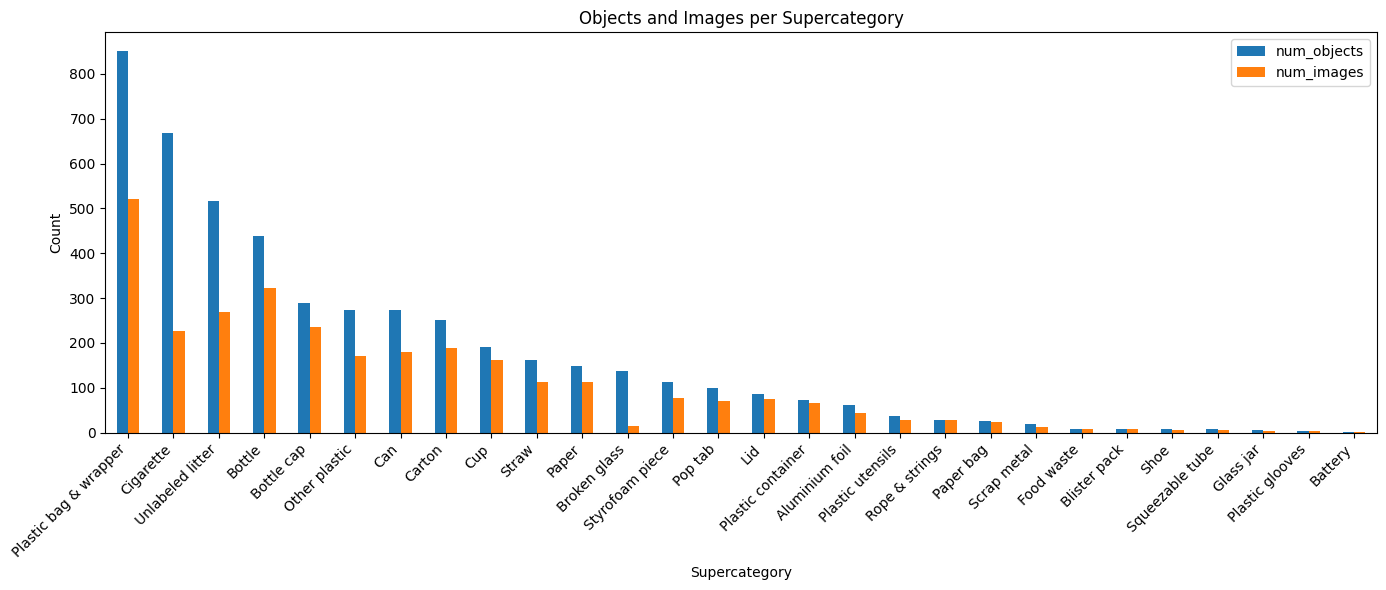

In [20]:
supercategory_summary_plot = supercategory_summary.set_index("supercategory")[
    ["num_objects", "num_images"]
]

supercategory_summary_plot.plot(
    kind="bar",
    figsize=(14, 6),
)

plt.title("Objects and Images per Supercategory")
plt.xlabel("Supercategory")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Category Summary

In [21]:
category_summary = (
    df.groupby(["category_id", "category_name", "supercategory"])
    .agg(
        num_objects=("image_id", "count"),
        num_images=("image_id", "nunique"),
    )
    .sort_values("num_objects", ascending=False)
    .reset_index()
)

category_summary.head(30)

,category_id,category_name,supercategory,num_objects,num_images
0,59,Cigarette,Cigarette,667,227
1,58,Unlabeled litter,Unlabeled litter,517,269
2,36,Plastic film,Plastic bag & wrapper,451,310
3,5,Clear plastic bottle,Bottle,285,225
4,29,Other plastic,Other plastic,273,171
5,39,Other plastic wrapper,Plastic bag & wrapper,260,184
6,12,Drink can,Can,229,151
7,7,Plastic bottle cap,Bottle cap,209,185
8,55,Plastic straw,Straw,157,110
9,9,Broken glass,Broken glass,138,15


### Objects Per Image

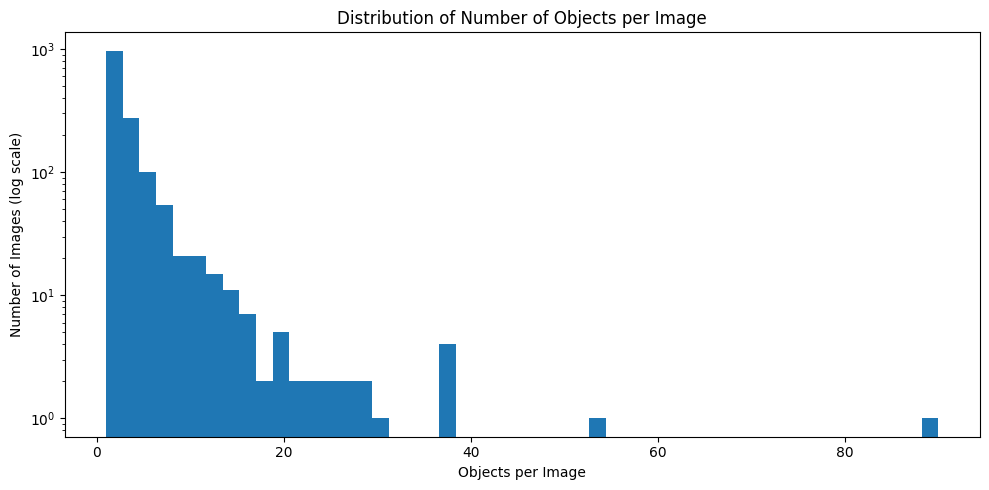

In [22]:
objects_per_image = df.groupby("image_id").size()

plt.figure(figsize=(10, 5))
plt.hist(objects_per_image, bins=50)

plt.yscale("log")

plt.title("Distribution of Number of Objects per Image")
plt.xlabel("Objects per Image")
plt.ylabel("Number of Images (log scale)")
plt.tight_layout()
plt.show()

### Scene Category Counts

In [23]:
df_scene_annotations["background_ids"] = df_scene_annotations["background_ids"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

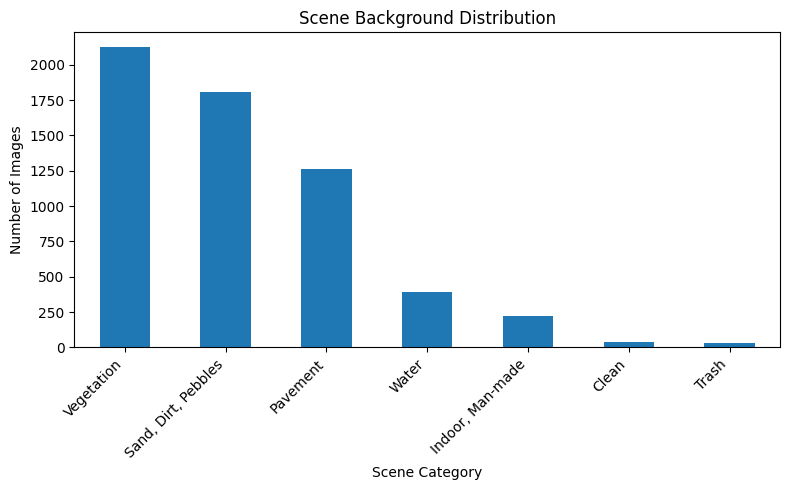

In [24]:
scene_counts = (
    df_scene_annotations
    .explode("background_ids")
    .merge(
        df_scene_categories,
        left_on="background_ids",
        right_on="id",
        how="left",
    )
    ["name"]
    .value_counts()
)

scene_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Scene Background Distribution")
plt.xlabel("Scene Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observation:

* The dataset contains diverse background types. This supports the idea that litter detection is a context-heavy task, not only an object-recognition task.
* `Vegetation`, `Sand, Dirt, Pebbles` and `Pavement` are the most common scene background

### Top Examples By Object Count

Show the top 3 images with most annotations:

In [25]:
top_image_ids = df.groupby("image_id").size().sort_values(ascending=False).head(3).index

for image_id in top_image_ids:
    print("image_id:", image_id, "objects:", len(df[df["image_id"] == image_id]))

image_id: 1107 objects: 90
image_id: 1321 objects: 54
image_id: 362 objects: 38


#### Observation:

* Some images contain a very high number of annotated objects. These images are valid for detection training, but they may increase memory usage and make batch-level training less stable.

### Category Imbalance Ratio

In [26]:
category_counts = df["category_name"].value_counts()

print("max category count:", category_counts.max())
print("min category count:", category_counts.min())
print("imbalance ratio:", category_counts.max() / category_counts.min())

max category count: 667
min category count: 1
imbalance ratio: 667.0


#### Observation:

* The category distribution is strongly imbalanced. This motivates later experiments with weighted sampling, classless detection, and reduced label taxonomies.

## Objects

### Bbox Size Distribution

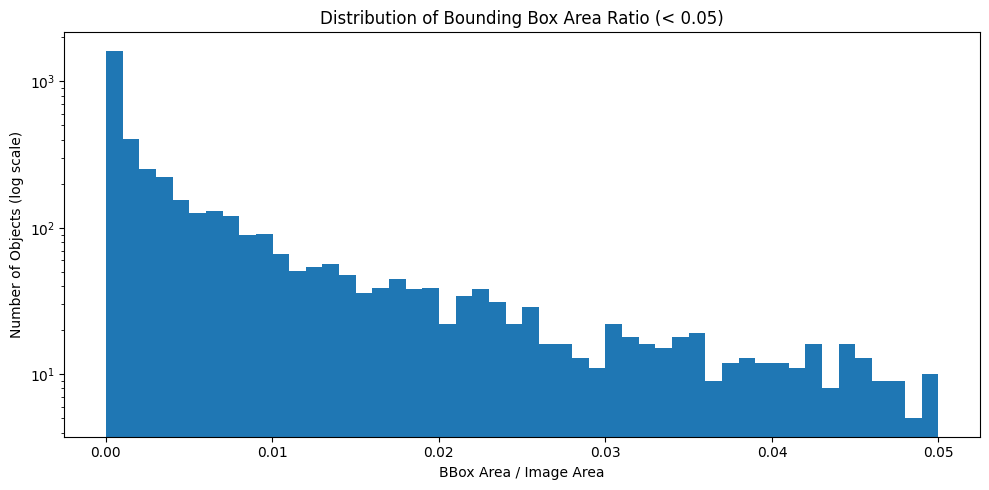

In [27]:
bbox_values = df["bbox"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df["bbox_w"] = bbox_values.apply(lambda b: b[2])
df["bbox_h"] = bbox_values.apply(lambda b: b[3])
df["bbox_area"] = df["bbox_w"] * df["bbox_h"]
df["image_area"] = df["width"] * df["height"]
df["bbox_area_ratio"] = df["bbox_area"] / df["image_area"]

plt.figure(figsize=(10, 5))
plt.hist(df[df["bbox_area_ratio"] < 0.05]["bbox_area_ratio"], bins=50)
plt.yscale("log")
plt.title("Distribution of Bounding Box Area Ratio (< 0.05)")
plt.xlabel("BBox Area / Image Area")
plt.ylabel("Number of Objects (log scale)")
plt.tight_layout()
plt.show()

Observation:

The distribution is highly skewed: many objects occupy only a tiny fraction of the image. This suggests that small-object detection will be one of the main challenges.

### Object Size Buckets

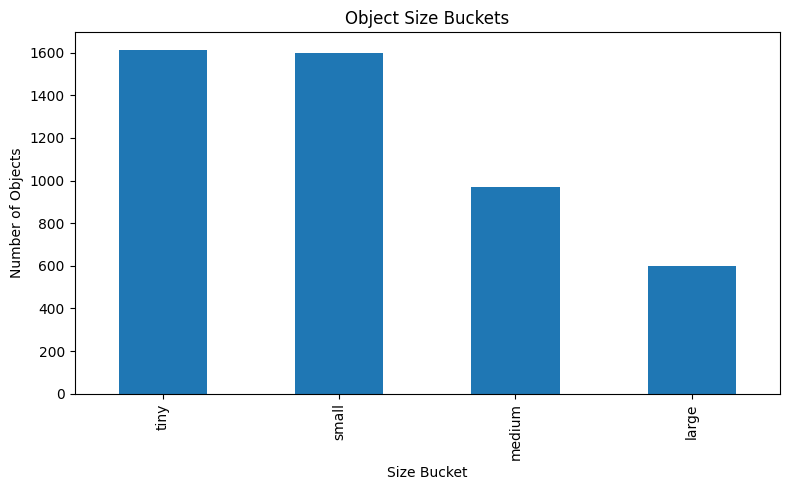

In [28]:
def bbox_size_bucket(area_ratio):
    if area_ratio < 0.001:
        return "tiny"
    if area_ratio < 0.01:
        return "small"
    if area_ratio < 0.05:
        return "medium"
    return "large"

df["bbox_size_bucket"] = df["bbox_area_ratio"].apply(bbox_size_bucket)

df["bbox_size_bucket"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Object Size Buckets")
plt.xlabel("Size Bucket")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

#### Observation:

A large fraction of annotations belongs to tiny or small objects. This explains why high-resolution input and careful evaluation are important for this dataset.

### Supercategory vs Size

In [29]:
size_by_supercategory = (
    df.groupby(["supercategory", "bbox_size_bucket"])
    .size()
    .reset_index(name="count")
)

size_by_supercategory

,supercategory,bbox_size_bucket,count
0,Aluminium foil,large,8
1,Aluminium foil,medium,18
2,Aluminium foil,small,28
3,Aluminium foil,tiny,8
4,Battery,large,1
...,...,...,...
97,Styrofoam piece,tiny,25
98,Unlabeled litter,large,11
99,Unlabeled litter,medium,29
100,Unlabeled litter,small,180


## Images

Let us inspect several dataset images.

### Raw image

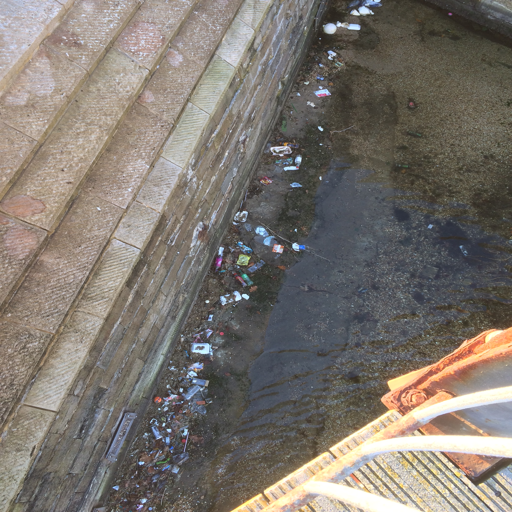

In [30]:
rows = df[df['image_id'] == 1107].copy()
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
img.resize((512, 512))

#### Observations

1. There are many annotated objects in this image.
2. Most of them are very small relative to the full image.

### Bbox

Now let us display all the bboxes for the image

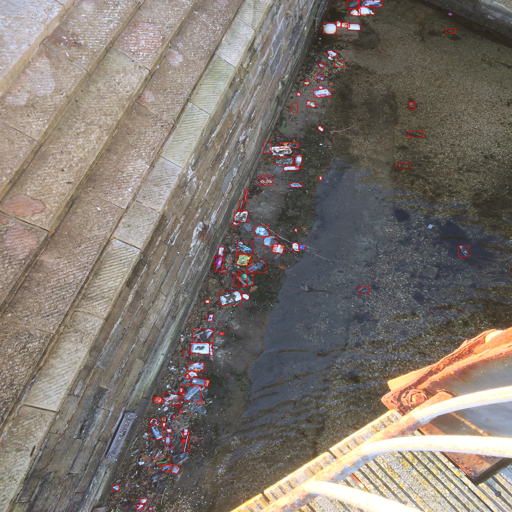

In [31]:
rows = df[df['image_id'] == 1107].copy()
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
draw = ImageDraw.Draw(img, "RGBA")
for row in rows.to_dict(orient='records'):
    bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
    x, y, w, h = bbox
    # Since coc format is [x_min, y_min, width, height]
    # and PIL accepts [x_min, y_min, x_max, y_max], so it requires transformation
    # x_max = x + width
    # y_max = y + height
    box = [x, y, x + w, y + h]
    draw.rectangle(box, outline="red", width=3)
img.resize((512, 512))

#### Observations

1. Compared with the image size, the bounding boxes are very small. This can complicate both training and inference.
2. Some of the trash / litter objects are difficult to notice with human eye
3. Some annotations may be ambiguous: a few marked objects are difficult to confidently identify as trash from visual inspection alone.

### Segmentation

Now it is time to display segmentation for this image

Let us look at how segmentation looks like:

In [32]:
segmentation = ast.literal_eval(rows.iloc[0]["segmentation"]) if isinstance(rows.iloc[0]["segmentation"], str) else rows.iloc[0]["segmentation"] 
segmentation

[[1044.0,
  1715.0,
  1053.0,
  1705.0,
  1056.0,
  1699.0,
  1057.0,
  1685.0,
  1059.0,
  1673.0,
  1064.0,
  1660.0,
  1068.0,
  1654.0,
  1067.0,
  1646.0,
  1064.0,
  1641.0,
  1063.0,
  1635.0,
  1052.0,
  1632.0,
  1040.0,
  1632.0,
  1034.0,
  1638.0,
  1031.0,
  1649.0,
  1029.0,
  1673.0,
  1025.0,
  1684.0,
  1023.0,
  1691.0,
  1024.0,
  1700.0,
  1027.0,
  1711.0,
  1030.0,
  1715.0,
  1033.0,
  1720.0,
  1032.0,
  1728.0,
  1042.0,
  1726.0,
  1044.0,
  1715.0]]

This list is a sequence of coordinates, like

```python
[x1, y1, x2, y2, x3, y3, ...]
```

It needs to be transformed into a list of coordinate pairs:

```python
[(x1, y1), (x2, y2), (x3, y3)]
```

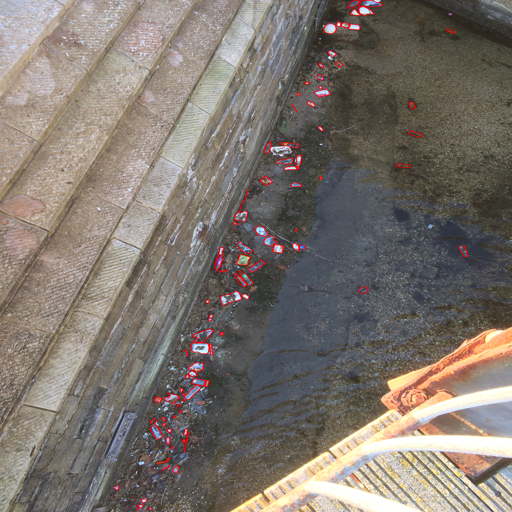

In [33]:
rows = df[df['image_id'] == 1107]
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
draw = ImageDraw.Draw(img, "RGBA")
for row in rows.to_dict(orient='records'):
    segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
    for seg in segmentation:
        # Iterate through the list with step 2
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]
        draw.polygon(
            polygon,
            # For filling the object completely
            # fill=(0, 255, 0, 80),
            outline="red",
            width=5
        )
img.resize((512, 512))

#### Observations

* The segmentation masks highlight how small and irregular many objects are. This makes instance segmentation more difficult than simple bounding-box detection.

### Categories

Let us check which categories these objects belong to.

In [34]:
rows = df[df['image_id'] == 1107].copy()
rows['category_id'].unique()

array([ 5,  4, 58, 29, 20, 39, 36, 12, 27, 55,  7])

This image contains `90` annotated objects from `11` unique categories. This illustrates both object density and category diversity within a single image.

## Other image

Let us inspect another image with fewer objects.

### Raw

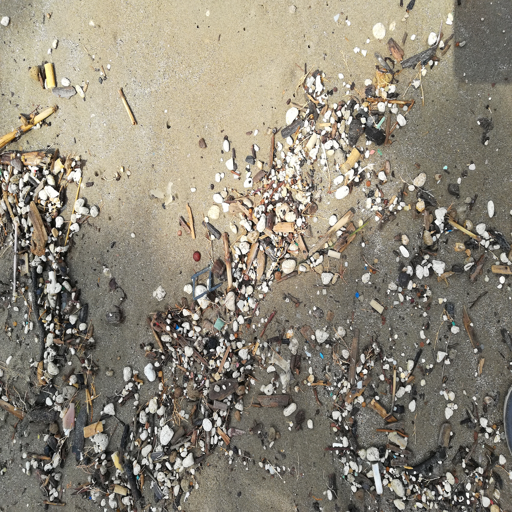

In [35]:
rows = df[df['image_id'] == 352].copy()
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
img.resize((512, 512))

This image is also challenging: actual trash is mixed with natural background objects.

### Bbox

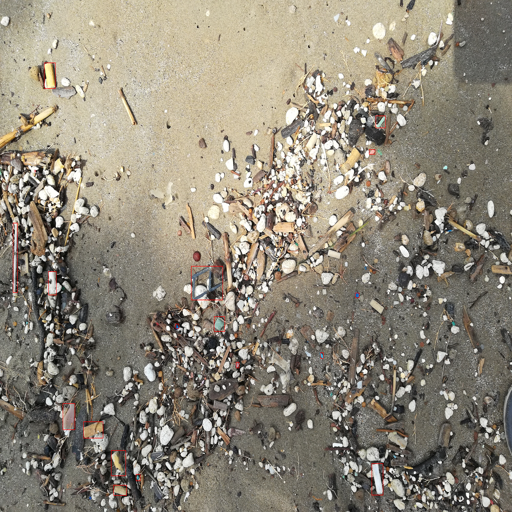

In [36]:
rows = df[df['image_id'] == 352].copy()
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
draw = ImageDraw.Draw(img, "RGBA")
for row in rows.to_dict(orient='records'):
    bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
    x, y, w, h = bbox
    # Since coc format is [x_min, y_min, width, height]
    # and PIL accepts [x_min, y_min, x_max, y_max], so it requires transformation
    # x_max = x + width
    # y_max = y + height
    box = [x, y, x + w, y + h]
    draw.rectangle(box, outline="red", width=3)
img.resize((512, 512))

From bounding boxes alone, some objects are almost impossible to recognize visually.

### Segmentation

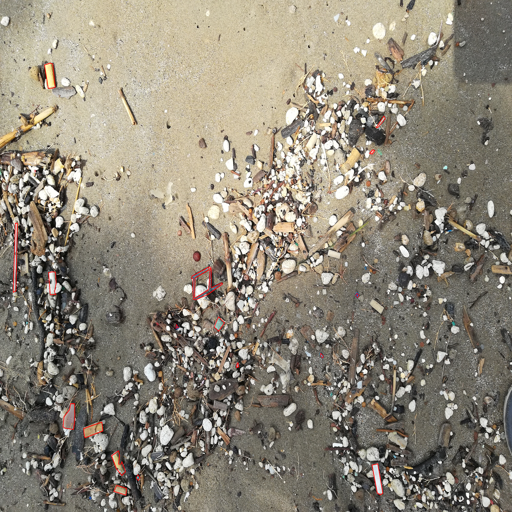

In [37]:
rows = df[df['image_id'] == 352].copy()
file_url = rows.iloc[0]['flickr_url']
img = Image.open(requests.get(file_url, stream=True).raw)
draw = ImageDraw.Draw(img, "RGBA")
for row in rows.to_dict(orient='records'):
    segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
    for seg in segmentation:
        # Iterate through the list with step 2
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]
        draw.polygon(
            polygon,
            # For filling the object completely
            # fill=(0, 255, 0, 80),
            outline="red",
            width=5
        )
img.resize((512, 512))

The segmentation view makes the annotated objects easier to see.

However, some annotations remain ambiguous because the objects are mixed with background clutter.

## Scene

Based on the previous image, can we find more examples with noisy or cluttered backgrounds?

In [38]:
rows

,id,image_id,category_id,segmentation,area,bbox,iscrowd,id_img,width,height,...,supercategory,id_cat,category_name,file_path,bbox_w,bbox_h,bbox_area,image_area,bbox_area_ratio,bbox_size_bucket
1177,1177,352,29,"[[2911, 743, 2928, 744, 2988, 688, 2975, 672]]",1479.5,"[2911.0, 672.0, 77.0, 72.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,77.0,72.0,5544.0,11808768,0.000469,tiny
1178,1178,352,59,"[[342, 376, 372, 515, 406, 514, 430, 507, 410,...",9246.0,"[342.0, 364.0, 88.0, 151.0]",0,352,3968,2976,...,Cigarette,59,Cigarette,/content/taco/batch_12/000051.jpg,88.0,151.0,13288.0,11808768,0.001125,small
1179,1179,352,59,"[[100, 1701, 117, 1295, 136, 1295, 125, 1692]]",8770.0,"[100.0, 1295.0, 36.0, 406.0]",0,352,3968,2976,...,Cigarette,59,Cigarette,/content/taco/batch_12/000051.jpg,36.0,406.0,14616.0,11808768,0.001238,small
1180,1180,352,59,"[[900, 2725, 861, 2648, 919, 2617, 928, 2647, ...",7279.0,"[861.0, 2617.0, 114.0, 149.0]",0,352,3968,2976,...,Cigarette,59,Cigarette,/content/taco/batch_12/000051.jpg,114.0,149.0,16986.0,11808768,0.001438,small
1181,1181,352,29,"[[2880, 2701, 2922, 2867, 2946, 2878, 2969, 28...",8574.0,"[2880.0, 2693.0, 89.0, 185.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,89.0,185.0,16465.0,11808768,0.001394,small
1182,1182,352,29,"[[2483, 2070, 2502, 2084, 2507, 2069, 2483, 20...",429.5,"[2483.0, 2049.0, 24.0, 35.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,24.0,35.0,840.0,11808768,0.000071,tiny
1183,1183,352,29,"[[1829, 2124, 1831, 2139, 1853, 2133, 1844, 21...",478.5,"[1829.0, 2104.0, 24.0, 35.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,24.0,35.0,840.0,11808768,0.000071,tiny
1184,1184,352,29,"[[1663, 1889, 1693, 1839, 1742, 1876, 1695, 19...",3789.0,"[1659.0, 1839.0, 83.0, 88.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,83.0,88.0,7304.0,11808768,0.000619,tiny
1185,1185,352,29,"[[1367, 1882, 1386, 1905, 1360, 1910]]",346.5,"[1360.0, 1882.0, 26.0, 28.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,26.0,28.0,728.0,11808768,0.000062,tiny
1186,1186,352,29,"[[1053, 2779, 1067, 2756, 1087, 2775, 1071, 27...",671.0,"[1053.0, 2756.0, 34.0, 39.0]",0,352,3968,2976,...,Other plastic,29,Other plastic,/content/taco/batch_12/000051.jpg,34.0,39.0,1326.0,11808768,0.000112,tiny


In [39]:
df_scene_annotations[df_scene_annotations['image_id'] == 352]

,image_id,background_ids
852,352,"[5, 2, 3]"
952,352,"[5, 3]"
1052,352,"[5, 3]"
1152,352,[5]
1252,352,[3]


In [40]:
df_scene_categories

,id,name
0,0,Clean
1,1,"Indoor, Man-made"
2,2,Pavement
3,3,"Sand, Dirt, Pebbles"
4,4,Trash
5,5,Vegetation
6,6,Water


This image is marked with several scene/background labels: `"Sand, Dirt, Pebbles"`, `"Vegetation"`, and `"Pavement"`.

Scene category `3` corresponds to `"Sand, Dirt, Pebbles"`.

Other images with scene category `3`:

In [41]:
sand_df = df_scene_annotations[
    df_scene_annotations["background_ids"].apply(lambda ids: 3 in ids)
]

Let us sample several other images from this scene category.

In [42]:
vegetation_df = df_scene_annotations[
    df_scene_annotations["background_ids"].apply(lambda ids: 5 in ids)
]

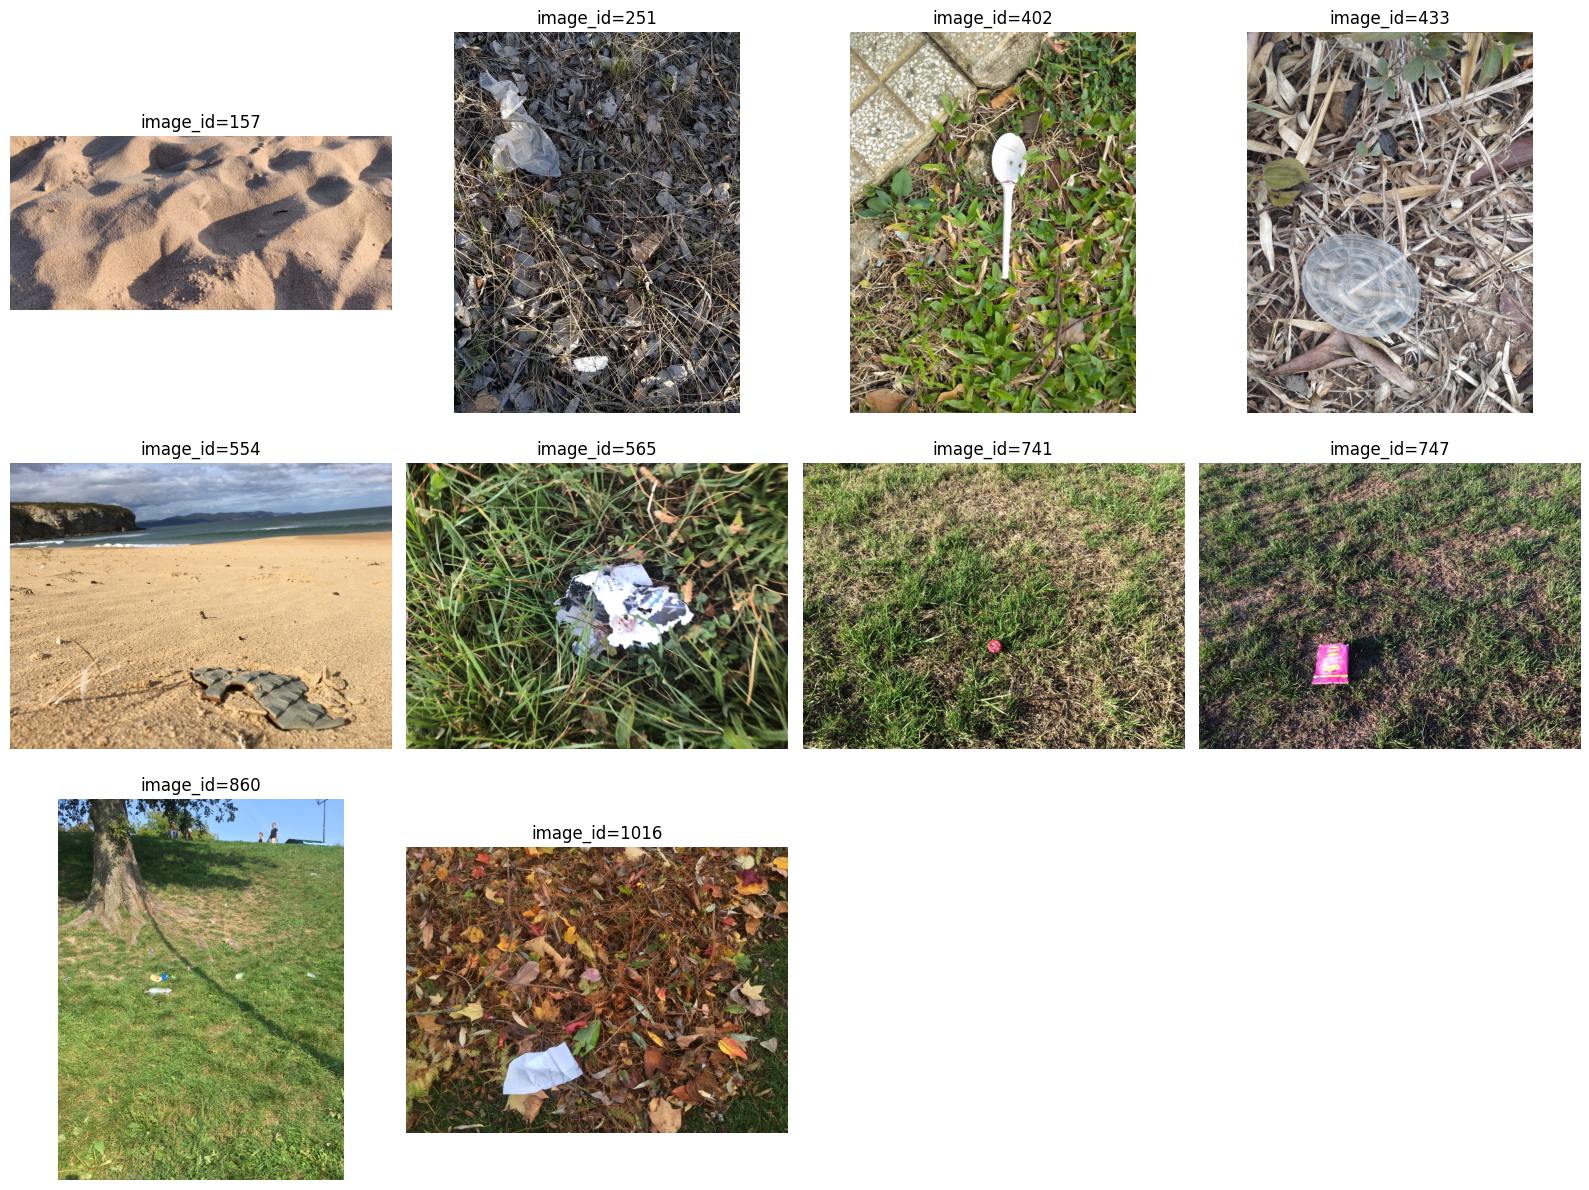

In [43]:
cols = 4
figsize_per_image = 4

image_ids = (
    vegetation_df["image_id"]
    .drop_duplicates()
    .sample(10, random_state=42)
)

subset_df = (
    df[df["image_id"].isin(image_ids)]
    .drop_duplicates("image_id")
)

image_paths = subset_df["flickr_url"].to_list()

rows = math.ceil(len(image_paths) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * figsize_per_image, rows * figsize_per_image),
)

axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, (_, row) in zip(axes, subset_df.iterrows()):
    img = Image.open(requests.get(row["flickr_url"], stream=True).raw).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"image_id={row['image_id']}")
    ax.axis("off")

for ax in axes[len(subset_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

These backgrounds can make both detection and classification harder because litter objects may be small, partially occluded, or visually similar to the surrounding scene.

## Conclusions

The exploratory analysis shows several important properties of the dataset:

1. The dataframe is object-level: one image can contain multiple annotated objects.
2. The dataset has many fine-grained categories and supercategories, which creates a difficult
multiclass task.
1. The category distribution is highly imbalanced.
2. Many objects are very small relative to the image size.
3. Some images contain a large number of objects, including strong outliers.
4. Visual inspection shows cluttered backgrounds, small objects, and ambiguous annotations.
5. Scene labels confirm that objects appear in diverse environments such as vegetation, pavement, and
sand/dirt.

These observations motivate the later modeling experiments:
- classless vs multiclass detection;
- top-N category reduction;
- weighted sampling;
- object-size diagnostics;
- analysis of class confusion.